In [126]:
import numpy as np
import pandas as pd


### Import the training data into a df and check

In [127]:
train_df = pd.read_csv('dataset.csv')
train_df.head()
#Data has no wholes and can be worked with directly: train_df.isna().sum() = 0 for all sensors

#It is necessary to transform the timestam to timeseries since it is an object:
train_df = train_df.rename(columns={'Unnamed: 0': 'time'})
train_df['time'] = pd.to_datetime(train_df['time'])
#See if the time stamps are constant and complete:
print(train_df.iloc[:,0].max())
print(train_df.iloc[:,0].min())
time_step = pd.DataFrame(train_df['time'][1:].values - train_df['time'][:-1].values)
# All values are there the delta time step is constant


2012-03-14 23:55:00
2012-03-01 00:00:00


### See how the adj matrix looks like and how much are sensors to each other correlated

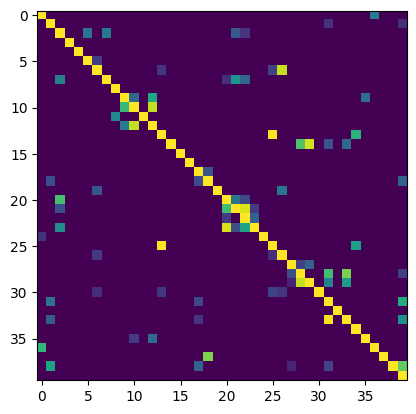

In [128]:
import matplotlib.pyplot as plt
adj_matrix = np.load('adj.npy')
plt.imshow(adj_matrix)
plt.show()

### See the behavior of one sensor to see paterns or seasonality

this many outlayers over 100 10
this many 0 meassures 173


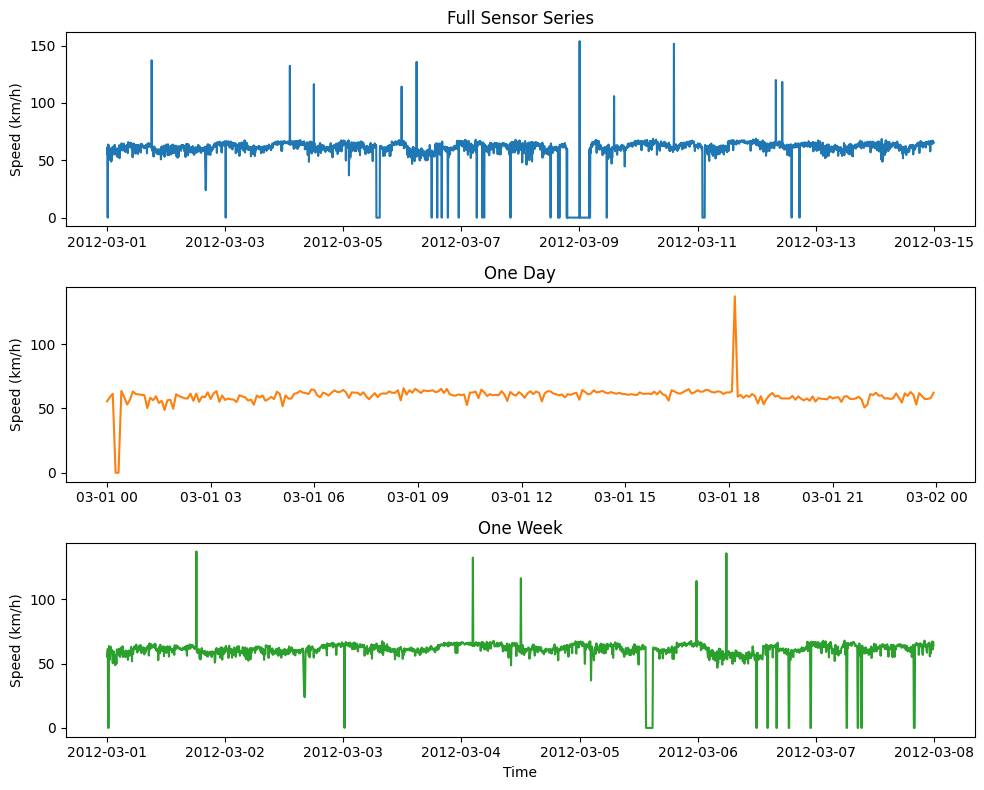

In [129]:
# Select sensor data
one_sensor = train_df.iloc[:,0:2]
#From the plot: Outlayers from speeding to more than 100kmh and parts where the sensor registers 0 kmh
print(f'this many outlayers over 100 {one_sensor[one_sensor['10'] > 100]['10'].count()}')
print(f'this many 0 meassures {one_sensor[one_sensor['10'] == 0]['10'].count()}')
one_day_sensor = one_sensor.iloc[:12*24,:] #12 for each hour and 24 hours a day
one_week_sensor = one_sensor.iloc[:12*24*7,:] #12 for each hour and 24 hours a day and 7 days
# Create subplots: 3 rows, 1 column
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

# --- Plot 1: Full series ---
axes[0].plot(one_sensor['time'], one_sensor['10'], color='tab:blue')
axes[0].set_title('Full Sensor Series')
axes[0].set_ylabel('Speed (km/h)')

# --- Plot 2: One day ---
axes[1].plot(one_day_sensor['time'], one_day_sensor['10'], color='tab:orange')
axes[1].set_title('One Day')
axes[1].set_ylabel('Speed (km/h)')

# --- Plot 3: One week ---
axes[2].plot(one_week_sensor['time'], one_week_sensor['10'], color='tab:green')
axes[2].set_title('One Week')
axes[2].set_ylabel('Speed (km/h)')
axes[2].set_xlabel('Time')

# Adjust layout
plt.tight_layout()
plt.show()

### See behavior over the average of all sensors

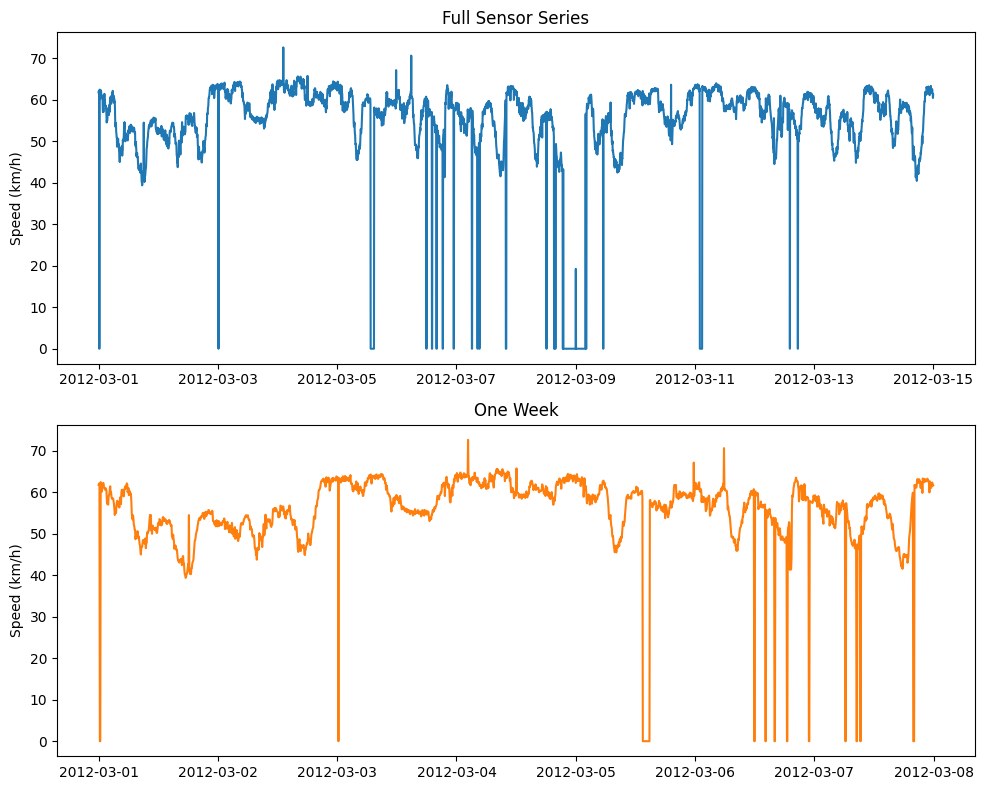

In [133]:
avg_speed = pd.DataFrame({'time': train_df['time'], 'avg_speed': train_df.iloc[:,1:].mean(axis=1)})
avg_speed_oneweek = pd.DataFrame({'time': train_df['time'][:12*24*7], 'avg_speed': train_df.iloc[:12*24*7,1:].mean(axis=1)})
# Create subplots: 3 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# --- Plot 1: Full series ---
axes[0].plot(avg_speed['time'], avg_speed['avg_speed'], color='tab:blue')
axes[0].set_title('Full Sensor Series')
axes[0].set_ylabel('Speed (km/h)')

# --- Plot 2: One Week ---
one_day_sensor = one_sensor.iloc[:12*24, :]
axes[1].plot(avg_speed_oneweek['time'], avg_speed_oneweek['avg_speed'], color='tab:orange')
axes[1].set_title('One Week')
axes[1].set_ylabel('Speed (km/h)')

# Adjust layout
plt.tight_layout()
plt.show()

### Handle outlayers and make data ready for model ussage:

In [ ]:
#Interpolate all the outlayers that are +- the 2*std but for each sensor
#Mean
for sensor in range(train_df.iloc[:,1:].shape[1]):
    train_df.iloc[sensor+1,:][]



count    4032.000000
mean       59.273658
std        13.437630
min         0.000000
25%        59.555556
50%        62.000000
75%        64.222222
max       153.808117
Name: 10, dtype: float64

In [144]:
# Assuming first column is 'time'
sensors = train_df.columns[1:]

# Compute mean and std for each sensor
mean = train_df[sensors].mean()
std = train_df[sensors].std()

# Mask values outside ±2 std and set to NaN
train_df[sensors] = train_df[sensors].mask(
    (train_df[sensors] > mean + 2*std) | (train_df[sensors] < mean - 2*std)
)

In [145]:
train_df.head()

,time,10,11,12,13,14,15,16,17,18,...,170,171,172,173,174,175,176,177,178,179
0,2012-03-01 00:00:00,55.500000,66.500000,64.250000,68.500000,60.375000,67.500000,37.75,63.125000,59.750000,...,58.375000,64.500000,63.625000,63.750000,53.625000,69.875000,64.750000,62.375000,64.750000,52.125000
1,2012-03-01 00:05:00,58.777778,58.444444,66.444444,65.444444,56.111111,65.444444,39.00,63.777778,63.111111,...,55.333333,66.555556,66.555556,65.777778,59.888889,66.888889,67.444444,62.222222,62.222222,52.333333
2,2012-03-01 00:10:00,61.375000,62.375000,64.750000,65.250000,61.875000,67.875000,35.25,63.875000,35.625000,...,58.125000,64.625000,67.375000,66.750000,56.000000,68.750000,65.625000,61.000000,63.500000,56.125000
3,2012-03-01 00:15:00,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-03-01 00:20:00,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [142]:
len(train_df.iloc[:,1:])

4032

In [143]:
train_df.iloc[:,1:].shape

(4032, 40)